# Experiment III: The spectral form factor

In this experiment we will look at the spectral form factor (SFF) at different values of beta, and compare with our interpolation formula for 1 <= beta <= 4.

This is the most computationally heavy of our experiments, and the notebook takes a few hours to generate large samples of spectra from the Circular beta-ensemble (which we use because their spectra do not require unfolding), and then compute the SFF form each large sample.

We saved the data files generated by this notebook. They are attached to the Zenodo release.

In [1]:
# General imports
import numpy as np
import scipy
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

# Import beta_ensembles from source folder
import sys
from pathlib import Path
root_dir = Path.cwd().parent
sys.path.insert(0, str(root_dir / "src"))

import beta_ensembles as be

# Default plotting style
plt.style.use(['seaborn-v0_8','./plot_style.mplstyle'])

def savefig(fname):
    plt.savefig(str(Path.cwd().parent) + '\\figures\\' + fname + '.png')

In [2]:
# Moving average function, window is number of points to average over
def moving_average(t_grid, values, window):
    kernel = np.ones(window) / window
    avg = np.convolve(values, kernel, mode="valid")

    half = window // 2
    t_avg = t_grid[half:half + len(avg)]

    return t_avg, avg

First we generate large samples of CBE spectra for different values of beta. We especially want to see the interpolations from beta = 1 to 2, and from 2 to 4, as well as a few large values, greater than 4.


In [3]:
# Seeded RNG for exactly reproducible results
rng = np.random.default_rng(seed=sum(b'Ueda Akinari'))

# Generating all the spectra took around an hour. Instead of regenerating we load it from a file (attached in Zenodo release).
# Set to true to generate the spectra again. With the seeded rng, the notebook should generate exactly the same sample.
regenerate = False

# Beta values
beta_vals = [1.00, 1.25, 1.5, 1.75, 2.00, 2.5, 3.5, 4.0, 4.5, 6, 12, 24]
n_beta = len(beta_vals)

# Parameters
N = 200
n_spectra = 5000

# Place to save/load data
fname = str(Path.cwd().parent) + '\\data\\cbe_spectra_' + str(N) + '.npy'

if regenerate:
    # Generate all the spectra
    all_spectra = np.zeros((n_beta,n_spectra,N))

    for i, beta in enumerate(tqdm(beta_vals,desc='Total progress',position=1)):
        all_spectra[i] = be.circular.spectra(beta,N,n_spectra,rng,verbose=True)

    # Save to file:
    # np.save(fname,all_spectra)
else:
    # Load from file
    all_spectra = np.load(fname)

Here we compute the SFF for each sample, or load it from the file.

The function be.sff.compute_sff(...) returns both the full SFF and the connected part.

In [4]:
all_sff = []
all_conn = []

# Array of time values
t_grid = np.linspace(0,4,4000)

# Place to save/load results
fname_sff = str(Path.cwd().parent) + '\\data\\cbe_sff.npy'
fname_conn = str(Path.cwd().parent) + '\\data\\cbe_sff_conn.npy'

if regenerate:
    # Compute the SFFs
    for i in tqdm(range(n_beta),desc='Total progress',position=1):
        sff, conn = be.sff.compute_sff(all_spectra[i],t_grid,verbose=True)
        all_sff.append(sff)
        all_conn.append(conn)

    # Save to file:
    # np.save(fname_sff,all_sff)
    # np.save(fname_conn,all_conn)
else:
    # Load from file
    all_sff = np.load(fname_sff)
    all_conn = np.load(fname_conn)

And we plot the results for the connected part of the SFF for all the values of beta. We separate beta <= 4 from beta >= 4.

The result is in figure 6.7 in the note.

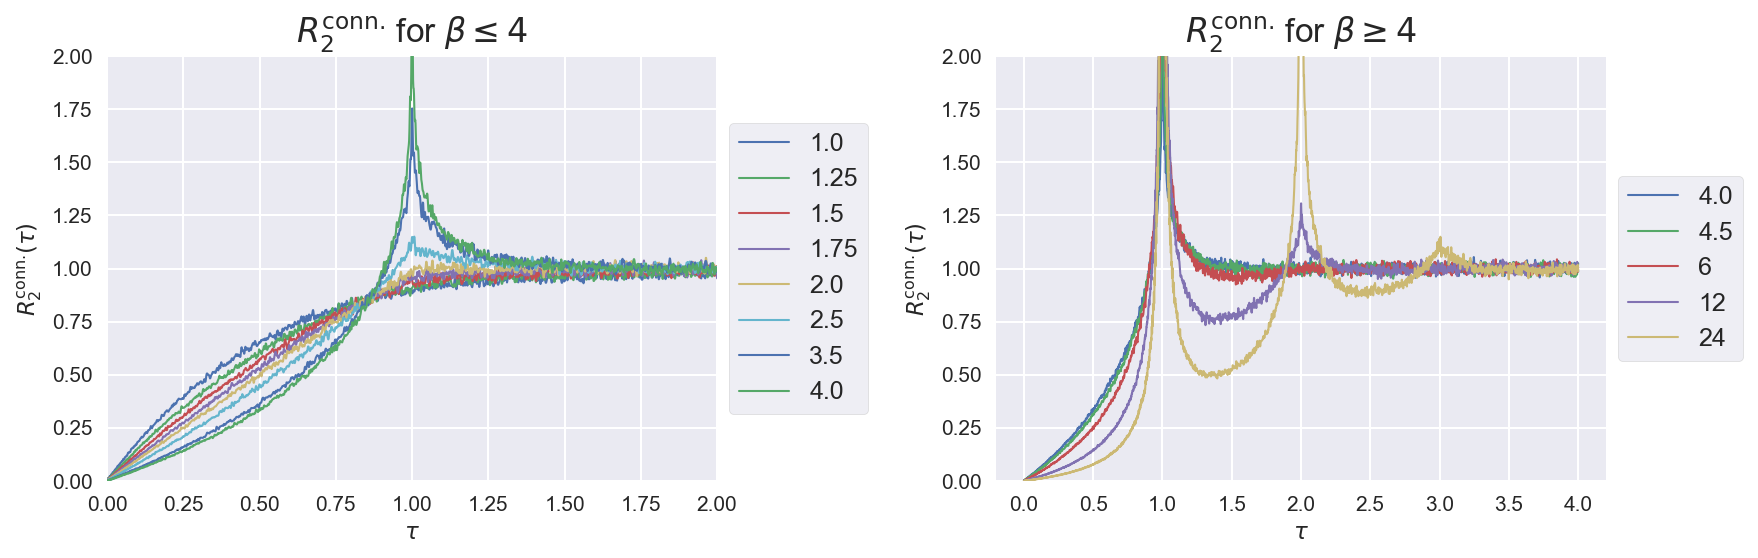

In [5]:
plt.subplots(1,2,figsize=(12,4))

plt.subplot(1,2,1)
for i in range(beta_vals.index(4)+1):
    plt.plot(t_grid,all_conn[i],label=f'{beta_vals[i]}',lw=1)

plt.xlabel(r'$\tau$')
plt.ylabel(r'$R_2^\text{conn.}(\tau)$')
plt.title(r'$R_2^\text{conn.}$ for $\beta\leq4$')

plt.xlim(0,2)
plt.ylim(0,2)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5));

plt.subplot(1,2,2)
for i in range(beta_vals.index(4),n_beta):
    plt.plot(t_grid,all_conn[i],label=f'{beta_vals[i]}',lw=1)
plt.ylim(0,2)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5));

plt.xlabel(r'$\tau$')
plt.ylabel(r'$R_2^\text{conn.}(\tau)$')
plt.title(r'$R_2^\text{conn.}$ for $\beta\geq4$')

plt.tight_layout()

# Save figure
# savefig('3a_temp')

Next, we compare the result with the predicted formula for 1 <= beta <= 4. We use a moving average to make the figure less noisy.

The deviation is small, but the CUE to CSE interpolation does not capture exactly the nature of the spike at tau = 1, so the deviations in the neighborhood of tau = 1 are larger.

This is again figure 6.7 of our note.

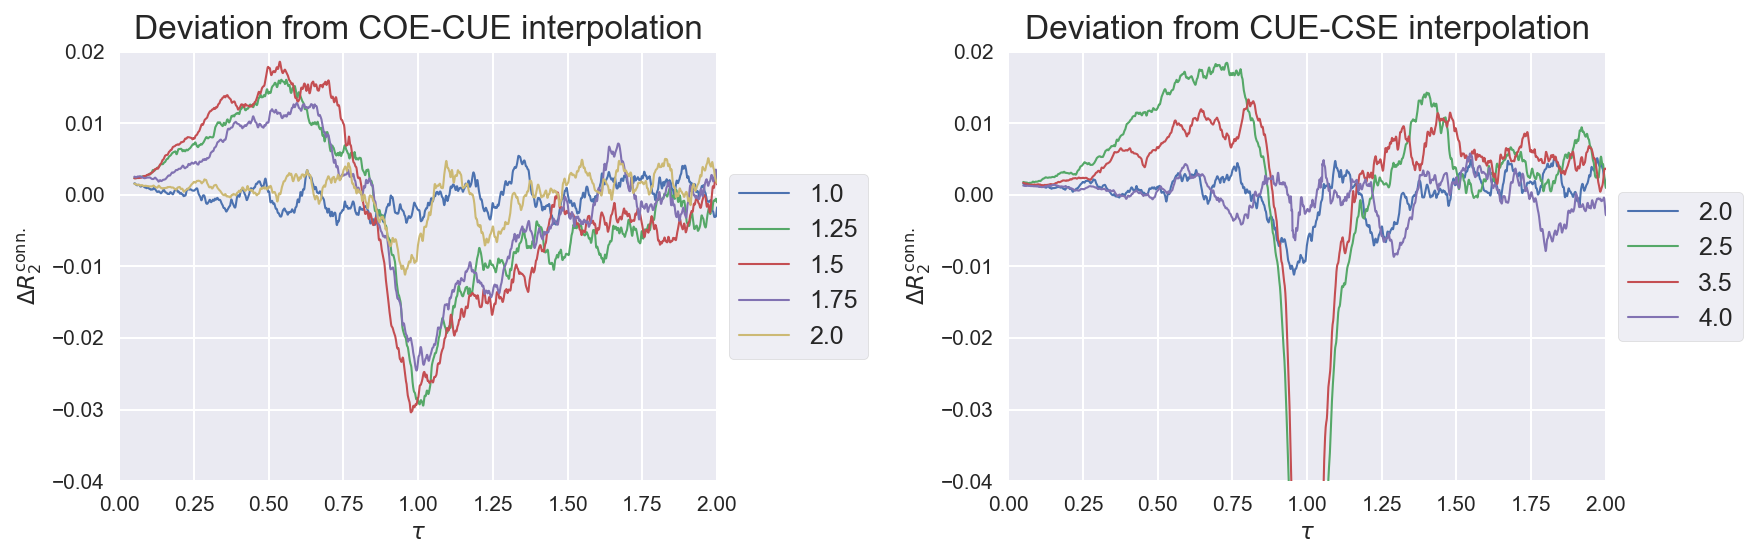

In [6]:
# Set window size of moving average
window = round(0.1 / (t_grid[1]-t_grid[0]))

plt.subplots(1,2,figsize=(12,4))

# Plot interpolation from 1 to 2
plt.subplot(1,2,1)
for i in range(0,beta_vals.index(2)+1):
    pred_sff = be.sff.predicted_sff(beta_vals[i], t_grid)
    diff = all_conn[i] - pred_sff
    t_avg, d_avg = moving_average(t_grid,diff,window)
    plt.plot(t_avg,d_avg,lw=1,label=f'{beta_vals[i]}')

plt.xlabel(r'$\tau$')
plt.ylabel(r'$\Delta R_2^\text{conn.}$')
plt.title(r'Deviation from COE-CUE interpolation')

plt.xlim(0,2)
plt.ylim(-0.04,0.02)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5));

# Plot interpolation from beta = 2 to 4
plt.subplot(1,2,2)
for i in range(beta_vals.index(2),beta_vals.index(4)+1):
    try:
        pred_sff = be.sff.predicted_sff(beta_vals[i], t_grid)
        diff = all_conn[i] - pred_sff
        t_avg, d_avg = moving_average(t_grid,diff,window)
        plt.plot(t_avg,d_avg,lw=1,label=f'{beta_vals[i]}')
    except:
        print(beta_vals[i])

plt.xlabel(r'$\tau$')
plt.ylabel(r'$\Delta R_2^\text{conn.}$')
plt.title(r'Deviation from CUE-CSE interpolation')

plt.ylim(-0.04,0.02)

plt.xlim(0,2)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5));


plt.tight_layout()

# Save figure
# savefig('3b_temp')